### Bước 3.0: Resume môi trường + copy dữ liệu vào local để train nhanh hơn

**Bài học quan trọng đã gặp:** đọc ảnh trực tiếp từ Google Drive (qua `flow_from_directory` trỏ vào đường dẫn `/content/drive/...`) rất chậm khi dataset lớn (~9 phút/epoch với 4503 ảnh train) vì phải đọc qua mạng. Cách xử lý: **copy dữ liệu vào ổ đĩa local `/content/` của Colab trước khi train** — nhanh hơn nhiều, chỉ mất công copy 1 lần mỗi session.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

PROJECT_ROOT = "/content/drive/MyDrive/waste-classification"
DATA_SPLIT_COMBINED_DIR = os.path.join(PROJECT_ROOT, "data/train_test_split_combined")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

print("Kiểm tra GPU:", tf.config.list_physical_devices('GPU'))

# Copy dữ liệu từ Drive vào local /content/ (chỉ copy nếu chưa có, vì mỗi session mất dữ liệu local)
LOCAL_DATA_DIR = "/content/data_local_combined"
if not os.path.exists(LOCAL_DATA_DIR):
    print("Đang copy dữ liệu từ Drive vào local...")
    shutil.copytree(DATA_SPLIT_COMBINED_DIR, LOCAL_DATA_DIR)
    print("Copy xong!")
else:
    print("Dữ liệu local đã có sẵn.")

# QUAN TRỌNG: luôn kiểm tra copy có ĐỦ 6 class, ĐỦ số ảnh hay không trước khi train.
# Lý do: nếu quá trình copy trước đó bị ngắt giữa chừng (mất mạng, vượt hạn mức Drive,
# session Colab bị disconnect...), thư mục LOCAL_DATA_DIR vẫn "tồn tại" (os.path.exists = True)
# nhưng có thể THIẾU nguyên 1 class -> code ở trên sẽ nghĩ là "đã có sẵn" và KHÔNG copy lại,
# dẫn tới train thiếu dữ liệu 1 class mà không có lỗi hay cảnh báo gì (rất khó phát hiện,
# chỉ lộ ra sau khi train xong thấy 1 class có precision/recall = 0.00).
print("\nKiểm tra dữ liệu local đã đủ 6 class chưa:")
du_lieu_thieu = False
for split in ['train', 'val', 'test']:
    print(f"\n{split}:")
    for cls in CLASS_NAMES:
        path = os.path.join(LOCAL_DATA_DIR, split, cls)
        if not os.path.exists(path) or len(os.listdir(path)) == 0:
            print(f"  {cls}: THIẾU / RỖNG ⚠️")
            du_lieu_thieu = True
        else:
            print(f"  {cls}: {len(os.listdir(path))} ảnh")

if du_lieu_thieu:
    print("\n>>> Phát hiện thiếu dữ liệu! Đang xóa và copy lại từ Drive để đảm bảo đủ...")
    shutil.rmtree(LOCAL_DATA_DIR)
    shutil.copytree(DATA_SPLIT_COMBINED_DIR, LOCAL_DATA_DIR)
    print(">>> Đã copy lại xong. Kiểm tra lại lần nữa:")
    for split in ['train', 'val', 'test']:
        print(f"\n{split}:")
        for cls in CLASS_NAMES:
            path = os.path.join(LOCAL_DATA_DIR, split, cls)
            n = len(os.listdir(path)) if os.path.exists(path) else "VẪN THIẾU ⚠️ - báo lỗi ngay, đừng train tiếp"
            print(f"  {cls}: {n}")
else:
    print("\nDữ liệu local đủ 6 class, an toàn để train.")

Mounted at /content/drive
Kiểm tra GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Đang copy dữ liệu từ Drive vào local...
Copy xong!

Kiểm tra dữ liệu local đã đủ 6 class chưa:

train:
  cardboard: 623 ảnh
  glass: 1416 ảnh
  metal: 538 ảnh
  paper: 735 ảnh
  plastic: 608 ảnh
  trash: 583 ảnh

val:
  cardboard: 133 ảnh
  glass: 303 ảnh
  metal: 115 ảnh
  paper: 157 ảnh
  plastic: 130 ảnh
  trash: 125 ảnh

test:
  cardboard: 135 ảnh
  glass: 305 ảnh
  metal: 116 ảnh
  paper: 158 ảnh
  plastic: 131 ảnh
  trash: 126 ảnh

Dữ liệu local đủ 6 class, an toàn để train.


### Bước 3.1: Hàm đánh giá dùng chung (khai báo lại nếu là notebook mới)

In [ ]:
def danh_gia_model(model, test_gen, ten_model="Model"):
    """Hàm dùng chung: in test accuracy, vẽ confusion matrix, in classification report."""
    test_loss, test_accuracy = model.evaluate(test_gen)
    print(f"[{ten_model}] Test Accuracy: {test_accuracy*100:.2f}% | Test Loss: {test_loss:.4f}")

    predictions = model.predict(test_gen)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_gen.classes

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Dự đoán')
    plt.ylabel('Thực tế')
    plt.title(f'Confusion Matrix - {ten_model}')
    plt.show()

    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    return y_true, y_pred

### Bước 3.2: Tạo generator (trỏ vào LOCAL_DATA_DIR) + tính class_weight + xây model

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.15, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator_combined = train_datagen.flow_from_directory(
    os.path.join(LOCAL_DATA_DIR, 'train'), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES
)
val_generator_combined = val_test_datagen.flow_from_directory(
    os.path.join(LOCAL_DATA_DIR, 'val'), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES
)
test_generator_combined = val_test_datagen.flow_from_directory(
    os.path.join(LOCAL_DATA_DIR, 'test'), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES, shuffle=False
)

train_labels_combined = train_generator_combined.classes
class_weight_dict_combined = dict(enumerate(compute_class_weight(
    class_weight='balanced', classes=np.unique(train_labels_combined), y=train_labels_combined
)))
print("class_weight_dict_combined:", class_weight_dict_combined)

# Kiến trúc GIỮ NGUYÊN như model_baseline gốc -> so sánh công bằng, chỉ khác dữ liệu
base_model_combined = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model_combined.trainable = False

x = base_model_combined.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(len(CLASS_NAMES), activation='softmax')(x)

model_baseline_combined = Model(inputs=base_model_combined.input, outputs=output)
model_baseline_combined.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Found 4503 images belonging to 6 classes.
Found 963 images belonging to 6 classes.
Found 971 images belonging to 6 classes.
class_weight_dict_combined: {0: np.float64(1.2046548956661316), 1: np.float64(0.5300141242937854), 2: np.float64(1.3949814126394051), 3: np.float64(1.0210884353741496), 4: np.float64(1.234375), 5: np.float64(1.2873070325900515)}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Bước 3.3: Train

In [ ]:
PATH_MODEL_BASELINE_COMBINED = os.path.join(PROJECT_ROOT, "models/mobilenetv2_baseline_combined.h5")

callbacks_baseline_combined = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(PATH_MODEL_BASELINE_COMBINED, monitor='val_accuracy', save_best_only=True)
]

history_baseline_combined = model_baseline_combined.fit(
    train_generator_combined,
    validation_data=val_generator_combined,
    epochs=20,
    class_weight=class_weight_dict_combined,
    callbacks=callbacks_baseline_combined
)

with open(os.path.join(PROJECT_ROOT, "models/history_baseline_combined.pkl"), "wb") as f:
    pickle.dump(history_baseline_combined.history, f)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.5930 - loss: 1.1119

141/141 ━━━━━━━━━━━━━━━━━━━━ 110s 644ms/step - accuracy: 0.7015 - loss: 0.8121 - val_accuracy: 0.8131 - val_loss: 0.5359
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.8100 - loss: 0.5119

141/141 ━━━━━━━━━━━━━━━━━━━━ 60s 425ms/step - accuracy: 0.8157 - loss: 0.5066 - val_accuracy: 0.8266 - val_loss: 0.4760
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.8354 - loss: 0.4588

141/141 ━━━━━━━━━━━━━━━━━━━━ 60s 424ms/step - accuracy: 0.8392 - loss: 0.4441 - val_accuracy: 0.8494 - val_loss: 0.4050
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.8518 - loss: 0.3907

141/141 ━━━━━━━━━━━━━━━━━━━━ 60s 429ms/step - accuracy: 0.8503 - loss: 0.3983 - val_accuracy: 0.8577 - val_loss: 0.4065
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.8690 - loss: 0.3700

...

141/141 ━━━━━━━━━━━━━━━━━━━━ 61s 431ms/step - accuracy: 0.8759 - loss: 0.3226 - val_accuracy: 0.8681 - val_loss: 0.3539
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.8873 - loss: 0.2801

141/141 ━━━━━━━━━━━━━━━━━━━━ 61s 434ms/step - accuracy: 0.8814 - loss: 0.2932 - val_accuracy: 0.8744 - val_loss: 0.3403
Epoch 9/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.8926 - loss: 0.2928

141/141 ━━━━━━━━━━━━━━━━━━━━ 59s 416ms/step - accuracy: 0.8901 - loss: 0.2921 - val_accuracy: 0.8764 - val_loss: 0.3443
Epoch 10/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.8938 - loss: 0.2665

141/141 ━━━━━━━━━━━━━━━━━━━━ 59s 418ms/step - accuracy: 0.8901 - loss: 0.2792 - val_accuracy: 0.8775 - val_loss: 0.3481
Epoch 11/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 59s 415ms/step - accuracy: 0.9025 - loss: 0.2414 - val_accuracy: 0.8692 - val_loss: 0.3427
Epoch 12/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 58s 412ms/step - accuracy: 0.9043 - loss: 0.2346 - val_accuracy: 0.8515 - val_loss: 0.3956
Epoch 13/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 59s 418ms/step - accuracy: 0.9134 - loss: 0.2109 - val_accuracy: 0.8692 - val_loss: 0.3290
Epoch 14/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 59s 419ms/step - accuracy: 0.9096 - loss: 0.2391 - val_accuracy: 0.8744 - val_loss: 0.3299
Epoch 15/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 60s 422ms/step - accuracy: 0.9156 - loss: 0.2153 - val_accuracy: 0.8733 - val_loss: 0.3332
Epoch 16/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9266 - loss: 0.2068

141/141 ━━━━━━━━━━━━━━━━━━━━ 60s 426ms/step - accuracy: 0.9229 - loss: 0.2067 - val_accuracy: 0.8858 - val_loss: 0.3272
Epoch 17/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 59s 415ms/step - accuracy: 0.9285 - loss: 0.1885 - val_accuracy: 0.8723 - val_loss: 0.3860
Epoch 18/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 58s 411ms/step - accuracy: 0.9274 - loss: 0.1875 - val_accuracy: 0.8744 - val_loss: 0.3475
Epoch 19/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 59s 419ms/step - accuracy: 0.9267 - loss: 0.1864 - val_accuracy: 0.8806 - val_loss: 0.3184
Epoch 20/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 59s 421ms/step - accuracy: 0.9340 - loss: 0.1706 - val_accuracy: 0.8816 - val_loss: 0.3548


### Bước 3.4: Vẽ biểu đồ

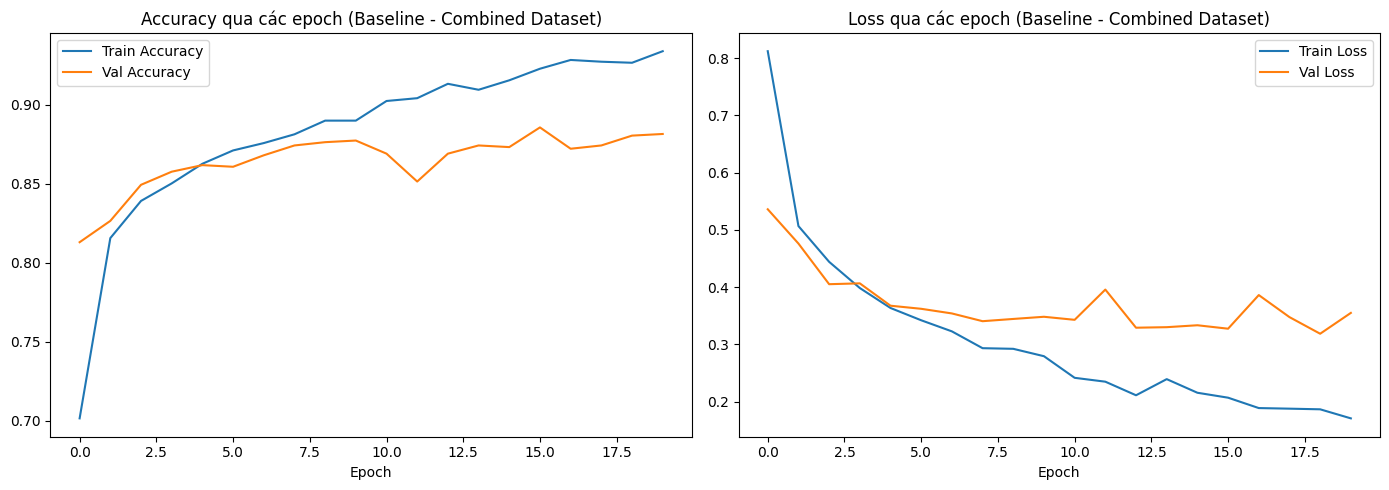

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(history_baseline_combined.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_baseline_combined.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy qua các epoch (Baseline - Combined Dataset)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_baseline_combined.history['loss'], label='Train Loss')
axes[1].plot(history_baseline_combined.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss qua các epoch (Baseline - Combined Dataset)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

### Bước 3.5: Đánh giá

31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 413ms/step - accuracy: 0.9032 - loss: 0.3096
[Baseline - Combined] Test Accuracy: 90.32% | Test Loss: 0.3096
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 195ms/step


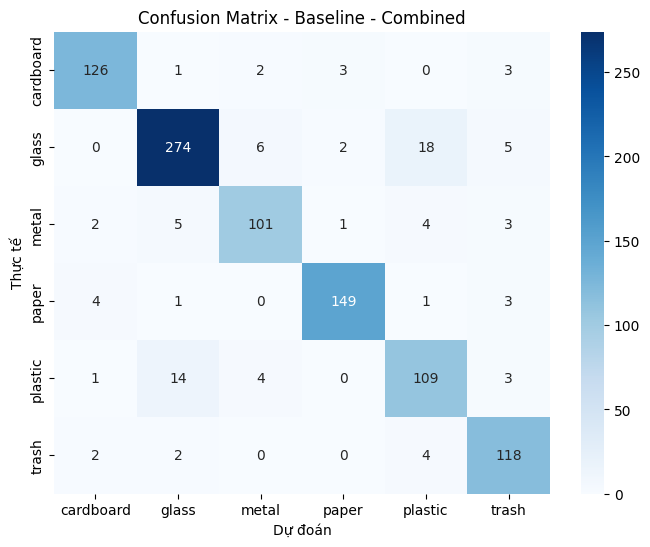

              precision    recall  f1-score   support

   cardboard       0.93      0.93      0.93       135
       glass       0.92      0.90      0.91       305
       metal       0.89      0.87      0.88       116
       paper       0.96      0.94      0.95       158
     plastic       0.80      0.83      0.82       131
       trash       0.87      0.94      0.90       126

    accuracy                           0.90       971
   macro avg       0.90      0.90      0.90       971
weighted avg       0.90      0.90      0.90       971



In [ ]:
y_true_baseline_combined, y_pred_baseline_combined = danh_gia_model(
    model_baseline_combined, test_generator_combined, "Baseline - Combined"
)

## Bước 4: Fine-tune model trên Combined Dataset

> Áp dụng đúng công thức "an toàn" đã rút ra từ Fine-tuned v1 (không lặp lại sai lầm của v2): `learning_rate=0.00001`, `fine_tune_at=100`.

### 4.1 Load lại model baseline (combined)

In [ ]:
PATH_MODEL_BASELINE_COMBINED = os.path.join(PROJECT_ROOT, "models/mobilenetv2_baseline_combined.h5")
model_finetuned_combined = tf.keras.models.load_model(PATH_MODEL_BASELINE_COMBINED)

### 4.2 Unfreeze layer cuối

In [ ]:
print("Tổng số layer:", len(model_finetuned_combined.layers))

base_model_layers = model_finetuned_combined.layers[:-4]
fine_tune_at = 100

for layer in base_model_layers:
    layer.trainable = False
for layer in base_model_layers[fine_tune_at:]:
    layer.trainable = True
for layer in model_finetuned_combined.layers[-4:]:
    layer.trainable = True

trainable_count = sum([1 for layer in model_finetuned_combined.layers if layer.trainable])
print(f"Số layer đang trainable: {trainable_count}/{len(model_finetuned_combined.layers)}")

Tổng số layer: 158
Số layer đang trainable: 58/158


### 4.3 Compile lại với learning rate nhỏ

In [ ]:
model_finetuned_combined.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 4.4 Train

In [ ]:
PATH_MODEL_FINETUNED_COMBINED = os.path.join(PROJECT_ROOT, "models/mobilenetv2_finetuned_combined.h5")
print("class_weight (giữ nguyên, không nhân thêm):", class_weight_dict_combined)

callbacks_finetune_combined = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True),
    ModelCheckpoint(PATH_MODEL_FINETUNED_COMBINED, monitor='val_accuracy', save_best_only=True)
]

history_finetune_combined = model_finetuned_combined.fit(
    train_generator_combined,
    validation_data=val_generator_combined,
    epochs=15,
    class_weight=class_weight_dict_combined,
    callbacks=callbacks_finetune_combined
)

with open(os.path.join(PROJECT_ROOT, "models/history_finetune_combined.pkl"), "wb") as f:
    pickle.dump(history_finetune_combined.history, f)

class_weight (giữ nguyên, không nhân thêm): {0: np.float64(1.2046548956661316), 1: np.float64(0.5300141242937854), 2: np.float64(1.3949814126394051), 3: np.float64(1.0210884353741496), 4: np.float64(1.234375), 5: np.float64(1.2873070325900515)}
Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.7570 - loss: 0.7464

141/141 ━━━━━━━━━━━━━━━━━━━━ 119s 670ms/step - accuracy: 0.7815 - loss: 0.6519 - val_accuracy: 0.8795 - val_loss: 0.3619
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.8256 - loss: 0.4995

141/141 ━━━━━━━━━━━━━━━━━━━━ 64s 449ms/step - accuracy: 0.8263 - loss: 0.4814 - val_accuracy: 0.8868 - val_loss: 0.3507
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.8447 - loss: 0.4179

141/141 ━━━━━━━━━━━━━━━━━━━━ 82s 454ms/step - accuracy: 0.8481 - loss: 0.4117 - val_accuracy: 0.8899 - val_loss: 0.3360
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 61s 436ms/step - accuracy: 0.8608 - loss: 0.3533 - val_accuracy: 0.8889 - val_loss: 0.3392
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.8699 - loss: 0.3339

141/141 ━━━━━━━━━━━━━━━━━━━━ 63s 445ms/step - accuracy: 0.8708 - loss: 0.3282 - val_accuracy: 0.8941 - val_loss: 0.3346
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 80s 433ms/step - accuracy: 0.8827 - loss: 0.3080 - val_accuracy: 0.8920 - val_loss: 0.3420
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 63s 451ms/step - accuracy: 0.8943 - loss: 0.2717 - val_accuracy: 0.8910 - val_loss: 0.3323
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9061 - loss: 0.2553

141/141 ━━━━━━━━━━━━━━━━━━━━ 64s 451ms/step - accuracy: 0.8994 - loss: 0.2635 - val_accuracy: 0.8962 - val_loss: 0.3297
Epoch 9/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 64s 454ms/step - accuracy: 0.8985 - loss: 0.2570 - val_accuracy: 0.8941 - val_loss: 0.3237
Epoch 10/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 62s 439ms/step - accuracy: 0.9054 - loss: 0.2406 - val_accuracy: 0.8951 - val_loss: 0.3171
Epoch 11/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.8933 - loss: 0.2687

141/141 ━━━━━━━━━━━━━━━━━━━━ 62s 440ms/step - accuracy: 0.9056 - loss: 0.2421 - val_accuracy: 0.8972 - val_loss: 0.3132
Epoch 12/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 61s 431ms/step - accuracy: 0.9149 - loss: 0.2219 - val_accuracy: 0.8962 - val_loss: 0.3084
Epoch 13/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9152 - loss: 0.2047

141/141 ━━━━━━━━━━━━━━━━━━━━ 63s 441ms/step - accuracy: 0.9169 - loss: 0.2058 - val_accuracy: 0.9034 - val_loss: 0.3034
Epoch 14/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 61s 431ms/step - accuracy: 0.9165 - loss: 0.2116 - val_accuracy: 0.9024 - val_loss: 0.3068
Epoch 15/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 60s 423ms/step - accuracy: 0.9269 - loss: 0.1907 - val_accuracy: 0.9024 - val_loss: 0.3051


### 4.5 Vẽ biểu đồ

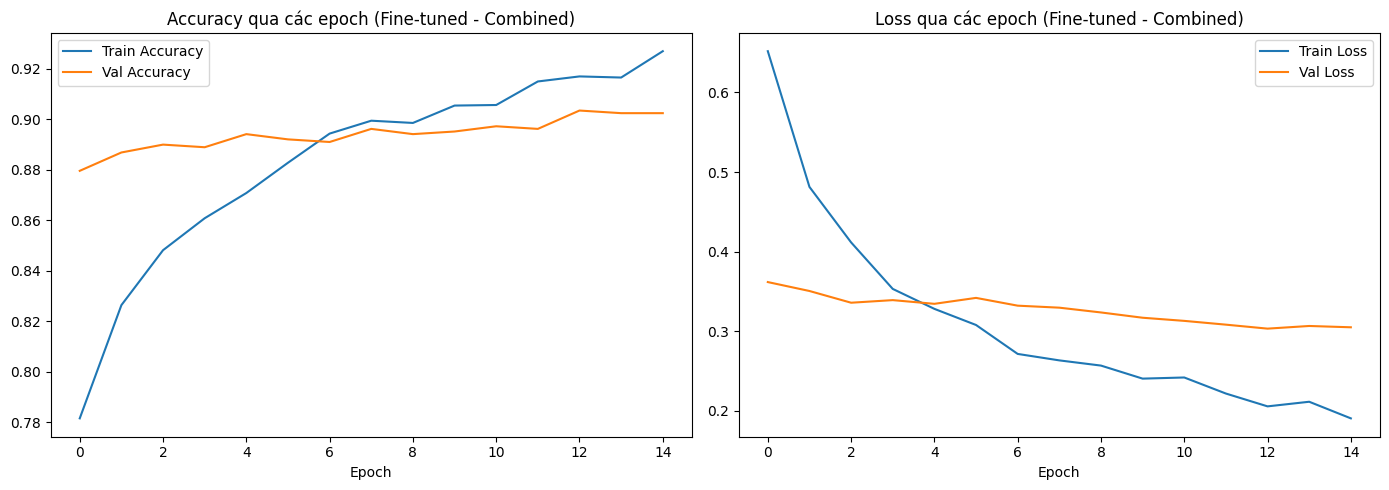

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(history_finetune_combined.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_finetune_combined.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy qua các epoch (Fine-tuned - Combined)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_finetune_combined.history['loss'], label='Train Loss')
axes[1].plot(history_finetune_combined.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss qua các epoch (Fine-tuned - Combined)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

### 4.6 Đánh giá

31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 154ms/step - accuracy: 0.9135 - loss: 0.2925
[Fine-tuned - Combined (từ checkpoint)] Test Accuracy: 91.35% | Test Loss: 0.2925
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 205ms/step


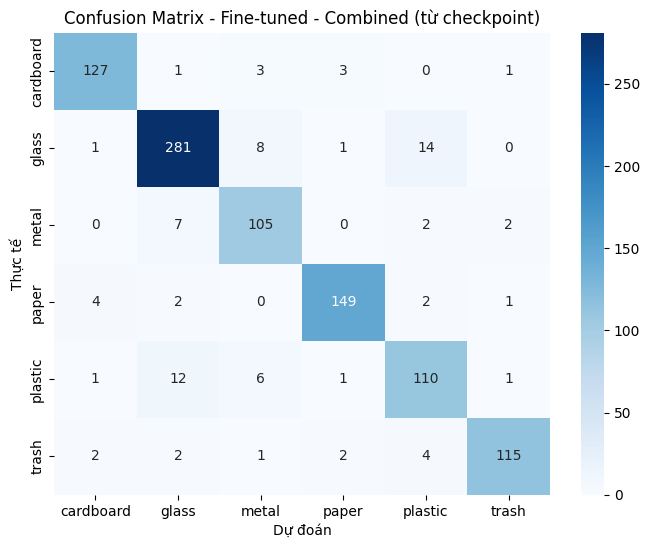

              precision    recall  f1-score   support

   cardboard       0.94      0.94      0.94       135
       glass       0.92      0.92      0.92       305
       metal       0.85      0.91      0.88       116
       paper       0.96      0.94      0.95       158
     plastic       0.83      0.84      0.84       131
       trash       0.96      0.91      0.93       126

    accuracy                           0.91       971
   macro avg       0.91      0.91      0.91       971
weighted avg       0.91      0.91      0.91       971



In [ ]:
model_finetuned_best = tf.keras.models.load_model(PATH_MODEL_FINETUNED_COMBINED)

y_true_finetuned_combined, y_pred_finetuned_combined = danh_gia_model(
    model_finetuned_best, test_generator_combined, "Fine-tuned - Combined (từ checkpoint)"
)

## Bảng so sánh tổng thể toàn bộ quá trình thực nghiệm (dùng cho phần "Kết quả" và "Thảo luận" của docx)

| Model | Dữ liệu | Test Accuracy | trash Precision | trash Recall | trash F1 |
|---|---|---|---|---|---|
| Baseline | TrashNet (2527 ảnh) | 82% | 0.51 | 0.82 | 0.63 |
| Fine-tuned v1 (lr=1e-5, unfreeze 55 layer) | TrashNet | 81% | 0.68 | 0.68 | 0.68 |
| Fine-tuned v2 (lr=1e-4, unfreeze 85 layer) | TrashNet | 79% | 0.68 | 0.59 | 0.63 |
| Baseline (Combined) | TrashNet + Garbage Classification (6437 ảnh) | 90% | 0.87 | 0.94 | 0.90 |
| **Fine-tuned (Combined)** (lr=1e-5, unfreeze 100 layer) | TrashNet + Garbage Classification | **91%** | **0.96** | **0.91** | **0.93** |

> ⚠️ **Lưu ý quan trọng khi đưa số liệu Combined vào docx:** lần chạy đầu tiên của Baseline/Fine-tuned Combined
> bị lỗi copy dữ liệu từ Drive sang local Colab thiếu hẳn phần `train`/`val` của class `trash` (xem chi tiết ở
> bảng "Các lỗi đã gặp thực tế" cuối file) → khiến class này ra kết quả precision/recall = 0.00 ở 2 lần chạy đó.
> Bảng trên là **số liệu đã chạy lại sau khi khắc phục lỗi**, chính xác và đáng tin cậy để dùng cho báo cáo.
> Không nên dùng số liệu 0.00 của trash ở các lần chạy lỗi trước.

**Kết luận chính (luận điểm cho phần Thảo luận):**
1. Tinh chỉnh hyperparameter (learning rate, số layer unfreeze) trên dữ liệu gốc **không cải thiện được** hiệu năng tổng thể khi dataset còn nhỏ, thậm chí làm giảm nhẹ accuracy và gây overfitting nặng hơn (rõ nhất ở v2).
2. **Tăng số lượng và đa dạng dữ liệu** — đặc biệt cho class yếu nhất (`trash`, từ 137 lên 834 ảnh gốc) — mang lại cải thiện vượt trội và toàn diện trên mọi class, không chỉ riêng `trash` (82% → 90%).
3. Khi đã có đủ dữ liệu nền tảng, **fine-tuning mới thực sự phát huy tác dụng** — Fine-tuned Combined (91%) cải thiện ổn định so với Baseline Combined (90%), không xảy ra overfitting như 2 lần fine-tune trên dataset nhỏ trước đó. Điều này cho thấy: lượng dữ liệu đủ lớn là điều kiện tiên quyết để fine-tuning phát huy hiệu quả, đúng với nguyên lý phổ biến trong Deep Learning.
4. **Model cuối cùng được chọn: `mobilenetv2_finetuned_combined.h5`** (91% test accuracy, F1-score mọi class đều ≥0.84) — dùng làm model tích hợp vào ứng dụng Streamlit.